# 17 - Daughter nodes placed by born fraction

Notebook 16: the even grid's error at large f̃ is a clean second-order quadrature error, because only
17 of 71 nodes fall inside the birth window. `accdm_q_log_share` = s places the nodes evenly in

$$u(\ln a) = s\,\frac{\ln a - \ln a_{\min}}{\ln(1/a_{\min})} + (1-s)\,\frac{F(a) - F_{\min}}{1 - F_{\min}},$$

so a share 1 − s of them follows the born fraction F (Simpson weights in u). s = 1 is the even grid;
the node count, and so the cost, does not change. Spec `2026-10-05-accdm-born-fraction-nodes-design`.

**Result.** s = 0.25 is now the default (since 2026-10-05; notebook 18 checked it across κ).
- At the default 71 nodes, s = 0.6 / 0.4 / 0.25 put 37 / 48 / 56 nodes inside the central 98% of births,
  against 17 for the even grid.
- Wherever the even grid's error was large, the born-fraction grids cut it by orders of magnitude at the
  same cost. Warm daughters: 50–2500× (10¹² GeV, f̃ = 0.9: Δχ² 207 → 0.08 at s = 0.25; 10¹¹ GeV,
  f̃ = 0.5: 2300 → 4.6). Cold daughters at f̃ = 0.9: 0.19–0.25 → 0.006–0.06.
- Runtime is unchanged or lower (median ratio 0.86–0.91); Ω_acc moves by ≤ 6·10⁻⁵ of the daughter
  density.
- Large errors remain only for the warmest daughters at large f̃ (10¹¹ GeV, f̃ ≥ 0.5), which also carry
  the `l_max_ncdm` error (notebook 19).
- Below a few 10⁻², comparisons hit the bin-independent Δχ² ≈ 0.041 jumps (notebooks 12, 16): 6 of the
  120 new runs, at any s. These are the only failures of the spec's criteria, and remain unexplained.

Settings, references and Δχ² as notebook 16, whose runs are read from `16_cache.pkl`; new runs in
`17_cache.pkl`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import (CONNECT_NEW, LCDM_NEW14_OCT05, OMEGA_DM_TOT_OCT05, RunCache, a_min, born_fraction,
                      chains_dir, compare, load_chain, mass_dirs, node_lna, ok, q_size, show, wquantile, plot_style)

plot_style()

SETTINGS = {**CONNECT_NEW, **LCDM_NEW14_OCT05, 'omega_dm_tot': OMEGA_DM_TOT_OCT05}
SHARES, NODE_BINS, REF, DCHI2_TOL, FLOOR = [0.6, 0.4, 0.25], [50, 100], 400, 0.1, 0.04
MASSES, F_GRID = [11, 12, 14, 16, 18], [0.01, 0.1, 0.5, 0.9]


def params(log10m, f_tilde, **extra):
    return {**SETTINGS, 'm_acc_in_GeV': 10.0**log10m, 'f_tilde': f_tilde, **extra}


F95 = {float(d.name): wquantile(s['f_tilde'], s['weight'], 0.95)
       for d in mass_dirs(chains_dir('k12.1a0.133')) for s in [load_chain(d)]}

## 0. Nodes in the birth window

q_size in 1–99% of births in 10–90% after 99%
s    bins/decade                                              
1.00 50              71                 17         8        37
     100            139                 33        16        72
0.60 50              71                 37        27        23
     100            139                 74        54        44
0.40 50              71                 48        37        15
     100            139                 94        72        30
0.25 50              71                 56        44        10
     100            139                110        87        19

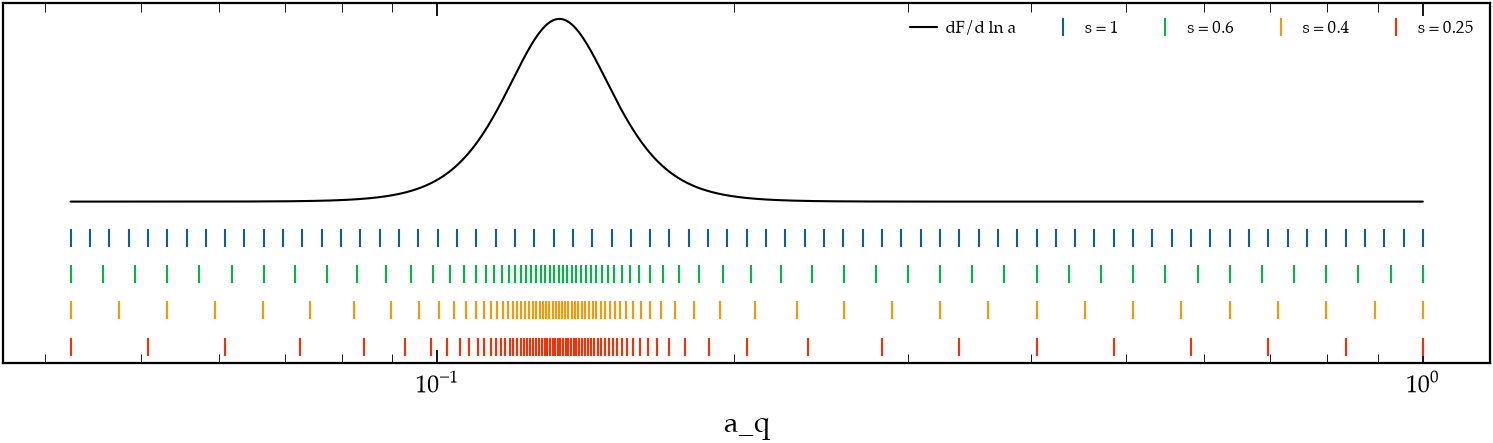

In [2]:
AMIN = a_min()
rows = []
for share in [1.0] + SHARES:
    for n in NODE_BINS:
        F = born_fraction(np.exp(node_lna(q_size(n, AMIN), share)))
        rows.append({'s': share, 'bins/decade': n, 'q_size': len(F), 'in 1–99% of births': int(np.sum((F > 0.01) & (F < 0.99))),
                     'in 10–90%': int(np.sum((F > 0.1) & (F < 0.9))), 'after 99%': int(np.sum(F >= 0.99))})
show(pd.DataFrame(rows).set_index(['s', 'bins/decade']), default='{:d}')

lna = np.linspace(np.log(AMIN), 0, 2000)
fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
ax.plot(np.exp(lna), np.gradient(born_fraction(np.exp(lna)), lna), 'k', lw=1, label='dF/d ln a')
for j, share in enumerate([1.0] + SHARES):
    a_nodes = np.exp(node_lna(q_size(50, AMIN), share))
    ax.plot(a_nodes, np.full_like(a_nodes, -0.6*(j + 1)), '|', ms=9, label='s = {:g}'.format(share))
ax.set_xscale('log')
ax.set_xlabel('a_q')
ax.set_yticks([])
ax.legend(fontsize=8, ncol=5)
plt.show()

## 1. Δχ² against the 400/decade references

In [3]:
cache = RunCache('17_cache.pkl', also=['16_cache.pkl'])
keys = [(lm, ft, s, n) for lm in MASSES for ft in F_GRID for n in NODE_BINS for s in [1.0] + SHARES]
grid = dict(zip(keys, cache.many([params(lm, ft, **({} if s == 1 else {'accdm_q_log_share': s}),
                                         accdm_q_bins_per_decade=n) for lm, ft, s, n in keys])))
ref = {(lm, ft): cache(params(lm, ft, accdm_q_bins_per_decade=REF)) for lm in MASSES for ft in F_GRID}
assert all(ok(r) for r in [*grid.values(), *ref.values()])

rows = []
for lm in MASSES:
    for ft in F_GRID:
        for n in NODE_BINS:
            old = grid[(lm, ft, 1.0, n)]
            row = {'log10 m': lm, 'f̃': ft, 'bins/dec': n, 'even grid': compare(old, ref[(lm, ft)])['total']}
            for s in SHARES:
                c = compare(grid[(lm, ft, s, n)], ref[(lm, ft)])
                row['s={:g}'.format(s)] = c['total']
                row['time ratio s={:g}'.format(s)] = grid[(lm, ft, s, n)]['sec']/old['sec']
                row['ΔΩ_acc s={:g}'.format(s)] = c['domega']
            rows.append(row)
cmp = pd.DataFrame(rows).set_index(['log10 m', 'f̃', 'bins/dec'])
show(cmp[['even grid'] + ['s={:g}'.format(s) for s in SHARES]], default='{:.2e}')

even grid     s=0.6     s=0.4    s=0.25
log10 m f̃   bins/dec                                        
11      0.01 50        9.01e-04  2.25e-05  4.50e-06  4.11e-02
             100       3.19e-04  2.30e-06  1.76e-07  1.37e-06
        0.10 50        1.45e+01  1.90e-01  7.46e-02  1.66e-02
             100       1.53e+00  7.35e-04  1.53e-03  2.14e-03
        0.50 50        2.32e+03  4.01e+01  1.13e+01  4.56e+00
             100       6.03e+02  2.96e-01  9.42e-02  1.65e-01
        0.90 50        1.04e+04  2.24e+02  4.38e+01  3.01e+01
             100       2.10e+03  2.67e+00  1.77e+00  1.65e+00
12      0.01 50        8.10e-06  3.52e-07  3.36e-07  7.54e-07
             100       1.49e-06  1.05e-07  8.52e-08  3.59e-07
        0.10 50        6.76e-02  1.61e-04  4.66e-05  8.79e-05
             100       2.04e-03  1.91e-04  1.46e-06  2.23e-05
        0.50 50        3.65e+01  1.54e-01  2.19e-02  1.57e-02
             100       1.32e+00  9.86e-03  8.05e-03  1.53e-02
        0.90 50        2.07e+02  6.06e-01  1.78e-01  8.18e-02
             100       7.93e+00  2.40e-02  2.74e-02  1.35e-02
14      0.01 50        1.58e-06  3.06e-07  1.67e-07  8.94e-07
             100       1.08e-06  1.33e-07  2.83e-07  3.33e-07
        0.10 50        2.61e-04  4.12e-02  1.39e-05  7.72e-05
             100       1.50e-04  1.18e-05  1.10e-05  3.41e-05
        0.50 50        5.80e-02  9.87e-04  4.61e-04  4.30e-02
             100       2.40e-03  9.01e-05  1.91e-03  1.54e-03
        0.90 50        2.15e-01  1.39e-02  2.67e-02  9.45e-03
             100       3.96e-02  1.81e-03  4.52e-03  9.85e-03
16      0.01 50        1.15e-06  4.16e-07  3.52e-07  1.16e-06
             100       1.18e-06  1.53e-07  2.47e-07  3.24e-07
        0.10 50        2.38e-05  4.78e-05  1.10e-05  8.92e-05
             100       4.09e-02  1.21e-05  4.07e-02  3.17e-05
        0.50 50        6.00e-02  1.48e-03  4.35e-04  2.70e-03
             100       2.12e-03  6.70e-04  1.49e-03  1.10e-03
        0.90 50        1.88e-01  1.01e-02  1.64e-02  6.53e-03
             100       7.20e-02  1.40e-03  5.74e-03  4.48e-03
18      0.01 50        1.09e-06  3.46e-07  4.54e-07  1.07e-06
             100       4.07e-02  1.29e-07  2.26e-07  3.21e-07
        0.10 50        1.64e-05  4.91e-05  1.06e-05  9.06e-05
             100       1.84e-04  4.07e-02  1.06e-05  3.20e-05
        0.50 50        6.44e-02  1.59e-03  4.59e-04  2.71e-03
             100       4.33e-02  6.73e-04  1.47e-03  1.08e-03
        0.90 50        2.49e-01  5.08e-02  5.68e-02  6.33e-03
             100       1.13e-01  4.21e-02  4.61e-02  4.49e-02

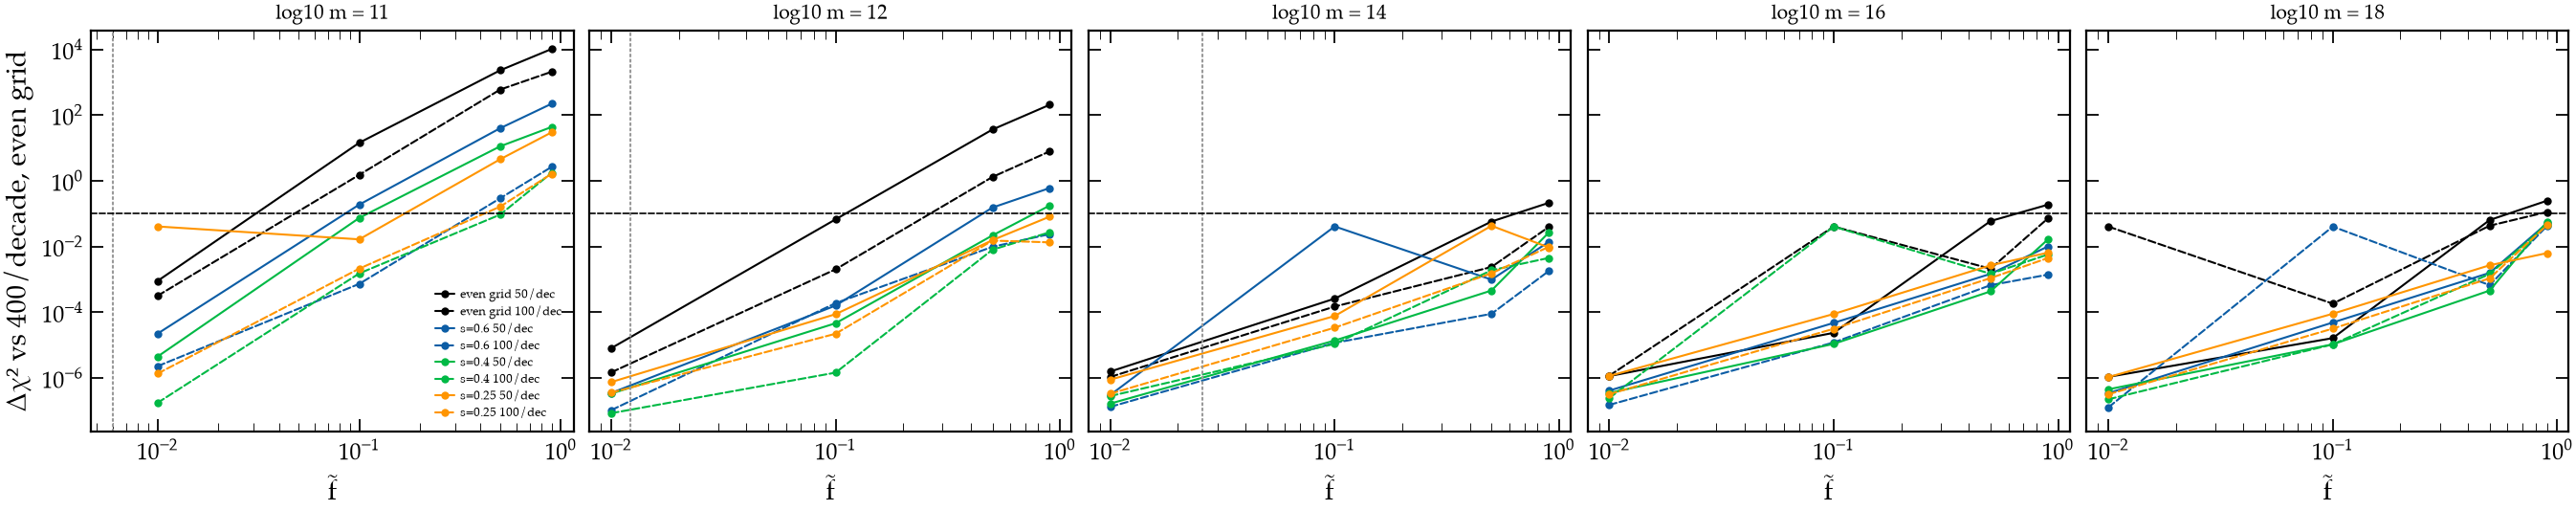

In [4]:
fig, axes = plt.subplots(1, len(MASSES), figsize=(3.6*len(MASSES), 3.6), sharey=True, constrained_layout=True)
for ax, lm in zip(axes, MASSES):
    for c, s in zip(('k', 'C0', 'C1', 'C2'), [1.0] + SHARES):
        for n, ls in zip(NODE_BINS, ('-', '--')):
            col = 'even grid' if s == 1 else 's={:g}'.format(s)
            ax.loglog(F_GRID, [max(cmp.loc[(lm, ft, n), col], 1e-9) for ft in F_GRID], ls, color=c, marker='o', ms=3,
                      lw=1, label='{} {}/dec'.format(col, n))
    if lm in F95:
        ax.axvline(F95[lm], color='0.6', ls=':', lw=1)
    ax.axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
    ax.set_title('log10 m = {:g}'.format(lm), fontsize=10)
    ax.set_xlabel('f̃')
axes[0].set_ylabel('Δχ² vs 400/decade, even grid')
axes[0].legend(fontsize=6)
plt.show()

## 2. The spec's criteria

At equal node count, per s: **gain**, the smallest Δχ²(even)/Δχ²(s) where the even grid exceeds 0.1
(needs ≥ 10); **worse**, points where s exceeds the even grid by more than the 0.04 floor (needs none);
**time**, the median runtime ratio (needs ≤ 1.1).

In [5]:
for n in NODE_BINS:
    sub = cmp.xs(n, level='bins/dec')
    big = sub['even grid'] > DCHI2_TOL
    print('{}/decade: {} points with even-grid Δχ² > {:g}'.format(n, int(big.sum()), DCHI2_TOL))
    for s in SHARES:
        col = 's={:g}'.format(s)
        gain = (sub.loc[big, 'even grid']/sub.loc[big, col]).min()
        worse = sub.index[sub[col] > sub['even grid'] + FLOOR].tolist()
        t = sub['time ratio ' + col].median()
        print('  s = {:<5g} gain {:>7.3g} [{}]   worse: {} [{}]   time {:.2f} [{}]'.format(
            s, gain, 'PASS' if gain >= 10 else 'FAIL', worse or 'none', 'FAIL' if worse else 'PASS', t,
            'PASS' if t <= 1.1 else 'FAIL'))

50/decade: 8 points with even-grid Δχ² > 0.1
  s = 0.6   gain    4.89 [FAIL]   worse: [(14, 0.1)] [FAIL]   time 0.87 [PASS]
  s = 0.4   gain    4.38 [FAIL]   worse: none [PASS]   time 0.86 [PASS]
  s = 0.25  gain    22.8 [PASS]   worse: [(11, 0.01)] [FAIL]   time 0.87 [PASS]
100/decade: 6 points with even-grid Δχ² > 0.1
  s = 0.6   gain    2.69 [FAIL]   worse: [(18, 0.1)] [FAIL]   time 0.87 [PASS]
  s = 0.4   gain    2.45 [FAIL]   worse: none [PASS]   time 0.89 [PASS]
  s = 0.25  gain    2.52 [FAIL]   worse: none [PASS]   time 0.91 [PASS]
